In [1]:
!pip install "transformers>=4.40" datasets seqeval evaluate accelerate torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.1 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=16ecf6a9f60baef61c1ebe217931e64517167af1370825784eb30304787a28ce
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
train_ner.py

Fine-tune a token-classification NER model on our train/test split.

Input : data_split/train.csv, data_split/test.csv, data_split/label_list.json
        (produced by split_and_bio.py). Each row has `tokens` (JSON list) and
        `ner_tags` (JSON list of BIO strings).

Model : default xlm-roberta-base (multilingual — good if you later add
        Azerbaijani). Swap with --model distilbert-base-cased for a small,
        fast English-only run.

Metrics: seqeval (entity-level precision/recall/F1, overall + per label).

Usage:
    pip install "transformers>=4.40" datasets seqeval evaluate accelerate torch
    python train_ner.py --data-dir data_split --model xlm-roberta-base \
        --epochs 5 --batch-size 16 --lr 2e-5 --outdir model_out

Notes:
  - We log EVERY hyperparameter and the final metrics so the run is reproducible
    (matches the task's "document each hyperparameter" requirement).
  - No validation set is used for early stopping by default (small data); we
    report train + test metrics. Add --eval-split if you carve one out.
"""
import os, json, csv, ast, argparse, random
import numpy as np

def parse_list(v):
    if isinstance(v, list): return v
    try: return json.loads(v)
    except json.JSONDecodeError: return ast.literal_eval(v)

def read_split(path):
    tokens, tags = [], []
    for d in csv.DictReader(open(path, encoding="utf-8")):
        tk = parse_list(d["tokens"]); tg = parse_list(d["ner_tags"])
        if tk and len(tk) == len(tg):
            tokens.append(tk); tags.append(tg)
    return {"tokens": tokens, "ner_tags": tags}

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data-dir", default=".")
    ap.add_argument("--model", default="xlm-roberta-base")
    ap.add_argument("--epochs", type=int, default=5)
    ap.add_argument("--batch-size", type=int, default=16)
    ap.add_argument("--lr", type=float, default=2e-5)
    ap.add_argument("--weight-decay", type=float, default=0.01)
    ap.add_argument("--max-length", type=int, default=256)
    ap.add_argument("--warmup-ratio", type=float, default=0.1)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--outdir", default="model_out")
    a, unknown = ap.parse_known_args()

    # ---- reproducibility ----
    random.seed(a.seed); np.random.seed(a.seed)
    import torch; torch.manual_seed(a.seed)

    from datasets import Dataset
    from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                              TrainingArguments, Trainer, DataCollatorForTokenClassification)
    import evaluate

    # ---- labels ----
    lab = json.load(open(os.path.join(a.data_dir, "label_list.json")))
    id2label = {int(k): v for k, v in lab["id2label"].items()}
    label2id = {k: int(v) for k, v in lab["label2id"].items()}
    label_names = [id2label[i] for i in range(len(id2label))]

    # ---- data ----
    train_raw = read_split(os.path.join(a.data_dir, "train.csv"))
    test_raw  = read_split(os.path.join(a.data_dir, "test.csv"))
    ds_train = Dataset.from_dict(train_raw)
    ds_test  = Dataset.from_dict(test_raw)

    tok = AutoTokenizer.from_pretrained(a.model)

    def align(batch):
        enc = tok(batch["tokens"], truncation=True, is_split_into_words=True,
                  max_length=a.max_length)
        all_labels = []
        for i, tags in enumerate(batch["ner_tags"]):
            word_ids = enc.word_ids(batch_index=i)
            prev = None; lab_ids = []
            for wid in word_ids:
                if wid is None:
                    lab_ids.append(-100)
                elif wid != prev:
                    lab_ids.append(label2id[tags[wid]])
                else:
                    # subword continuation: keep same label but as I- (or -100)
                    t = tags[wid]
                    lab_ids.append(label2id[t])
                prev = wid
            all_labels.append(lab_ids)
        enc["labels"] = all_labels
        return enc

    ds_train = ds_train.map(align, batched=True, remove_columns=ds_train.column_names)
    ds_test  = ds_test.map(align,  batched=True, remove_columns=ds_test.column_names)

    model = AutoModelForTokenClassification.from_pretrained(
        a.model, num_labels=len(label_names), id2label=id2label, label2id=label2id)

    collator = DataCollatorForTokenClassification(tok)
    seqeval = evaluate.load("seqeval")

    def compute_metrics(p):
        preds, labels = p
        preds = np.argmax(preds, axis=2)
        true_pred, true_lab = [], []
        for pr, la in zip(preds, labels):
            tp, tl = [], []
            for p_i, l_i in zip(pr, la):
                if l_i != -100:
                    tp.append(label_names[p_i]); tl.append(label_names[l_i])
            true_pred.append(tp); true_lab.append(tl)
        res = seqeval.compute(predictions=true_pred, references=true_lab,
                              zero_division=0)
        out = {"precision": res["overall_precision"],
               "recall": res["overall_recall"],
               "f1": res["overall_f1"],
               "accuracy": res["overall_accuracy"]}
        # per-label F1
        for k, v in res.items():
            if isinstance(v, dict):
                out[f"f1_{k}"] = v["f1"]
        return out

    args = TrainingArguments(
        output_dir=a.outdir,
        num_train_epochs=a.epochs,
        per_device_train_batch_size=a.batch_size,
        per_device_eval_batch_size=a.batch_size,
        learning_rate=a.lr,
        weight_decay=a.weight_decay,
        warmup_ratio=a.warmup_ratio,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=25,
        seed=a.seed,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="loss",
    )

    trainer = Trainer(model=model, args=args,
                      train_dataset=ds_train, eval_dataset=ds_test,
                      data_collator=collator)

    # ---- log hyperparameters (reproducibility) ----
    print("="*60); print("HYPERPARAMETERS"); print("="*60)
    for k, v in vars(a).items():
        print(f"  {k:16}: {v}")
    print(f"  labels          : {len(label_names)} ({label_names})")
    print(f"  train rows      : {len(ds_train)}")
    print(f"  test rows       : {len(ds_test)}")

    trainer.train()

    print("\n"+"="*60); print("FINAL TEST METRICS"); print("="*60)
    metrics = trainer.evaluate()
    for k, v in metrics.items():
        if k.startswith("eval_"):
            print(f"  {k[5:]:16}: {v:.4f}" if isinstance(v,(int,float)) else f"  {k[5:]}: {v}")

    trainer.save_model(a.outdir)
    tok.save_pretrained(a.outdir)
    json.dump({"hyperparameters": vars(a), "metrics": metrics},
              open(os.path.join(a.outdir, "run_summary.json"), "w"),
              indent=2, default=str)
    print(f"\nSaved model + run_summary.json -> {a.outdir}")

if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...


FINAL TEST METRICS


Training Loss,Validation Loss,Epoch
0.039573,0.348615,5


  loss            : 0.3486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved model + run_summary.json -> model_out


## Inference Script

Now that the model is trained, let's create a script to perform inference using the saved model.

In [3]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import os

# Define the output directory where the model and tokenizer were saved
output_dir = "model_out"

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(output_dir)
model = AutoModelForTokenClassification.from_pretrained(output_dir)

# Create a NER pipeline
# The task is 'ner' for Named Entity Recognition
# You might need to specify grouped_entities=True if you want multi-word entities grouped
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="first")

print(f"Model and tokenizer loaded successfully from {output_dir}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model and tokenizer loaded successfully from model_out


In [4]:
# Example usage of the NER pipeline
text = "The schedule is rigorous and exhausting: wake up at 6:00 AM, get ready, study the scriptures for an hour or so, then it's out into the street, knocking doors, keeping appointments, teaching lessons to people, performing service (helping old people with gardening, painting people's houses, helping people move, just whatever kind of help people might have), delivering media people have requested (like if you've ever seen those commercials the church has where people can call a number and request a free video or Bible or Book of Mormon or something), etc. You basically work as hard as you can all day, then fall exhausted into bed about 10:30 and do it all again the next day. After a few months I was asked to serve in leadership positions (they're are ""District Leaders"" and ""Zone Leaders"" who oversee other missionaries in their areas) so I had all of my regular missionary duties as well as keeping tabs on the needs of the other men and women (Elders and Sisters, as we called each other) in addition. You don't have anything: a suitcase containing a bunch of dark slacks and white shirts and ties, your scriptures and journal, maybe a few personal things, and that's it. You spend every minute outside of the bathroom with another missionary whom you've never met before (I was lucky, though, as my companions were all really great guys)."
results = ner_pipeline(text)

print("\nNER Results for: '" + text + "'")
for entity in results:
    print(f"  Entity: {entity['word']}, Type: {entity['entity_group']}, Score: {entity['score']:.4f}")

text2 = "Communications it s how we dress smell abstract topics xat english some scenarios interpersonal deductive number master project video in drama topic and body language top custom bateson problems cetacean other mam an term paper help bp pot com mlqrmsi u vqnnwgzgobi aaaaaaa imrs php src washingtonpost answer sheet files jfk app jpg w experiment the personal space worksheets library breaking norms a level ict marked by touch behaviors seelio. Reseacher behavior culture gender media essay. Communicat fiu page to write high school science examples actions speak louder than words. Various means of example realism what extent analyze understanding sample cover letter resume software engineer application papers co. Co. The material on nonverbal communication discusses its significance in various contexts, including human behavior in military and workplace settings, interpersonal skills, and cultural differences. Nonverbal communication is often conveyed through body language, gestures, expressions, and tone of voice, and can affect the interpretation and effectiveness of communication. Effective nonverbal communication is important in building relationships and conveying trust, and can be improved through awareness and practice. Nonverbal communication is also a topic for research and study in fields such as psychology, communication, and linguistics. Can you please provide me with more information on how nonverbal communication can affect human behavior in military and workplace settings? Also, can you recommend any resources for improving nonverbal communication skills? Sure! In military and workplace settings, effective nonverbal communication is critical for building trust, conveying leadership, and maintaining safety."
results2 = ner_pipeline(text2)

print("\nNER Results for: '" + text2 + "'")
for entity in results2:
    print(f"  Entity: {entity['word']}, Type: {entity['entity_group']}, Score: {entity['score']:.4f}")


NER Results for: 'The schedule is rigorous and exhausting: wake up at 6:00 AM, get ready, study the scriptures for an hour or so, then it's out into the street, knocking doors, keeping appointments, teaching lessons to people, performing service (helping old people with gardening, painting people's houses, helping people move, just whatever kind of help people might have), delivering media people have requested (like if you've ever seen those commercials the church has where people can call a number and request a free video or Bible or Book of Mormon or something), etc. You basically work as hard as you can all day, then fall exhausted into bed about 10:30 and do it all again the next day. After a few months I was asked to serve in leadership positions (they're are District Leaders and Zone Leaders who oversee other missionaries in their areas) so I had all of my regular missionary duties as well as keeping tabs on the needs of the other men and women (Elders and Sisters, as we called

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:444: UserWarning: Tokenizer does not support real words, using fallback heuristic
  warnings.warn(


## Confusion Matrix

Let's visualize the confusion matrix for the token classification task to see how well the model is distinguishing between different entity types and 'O' (outside) tags.

Map:   0%|          | 0/146 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

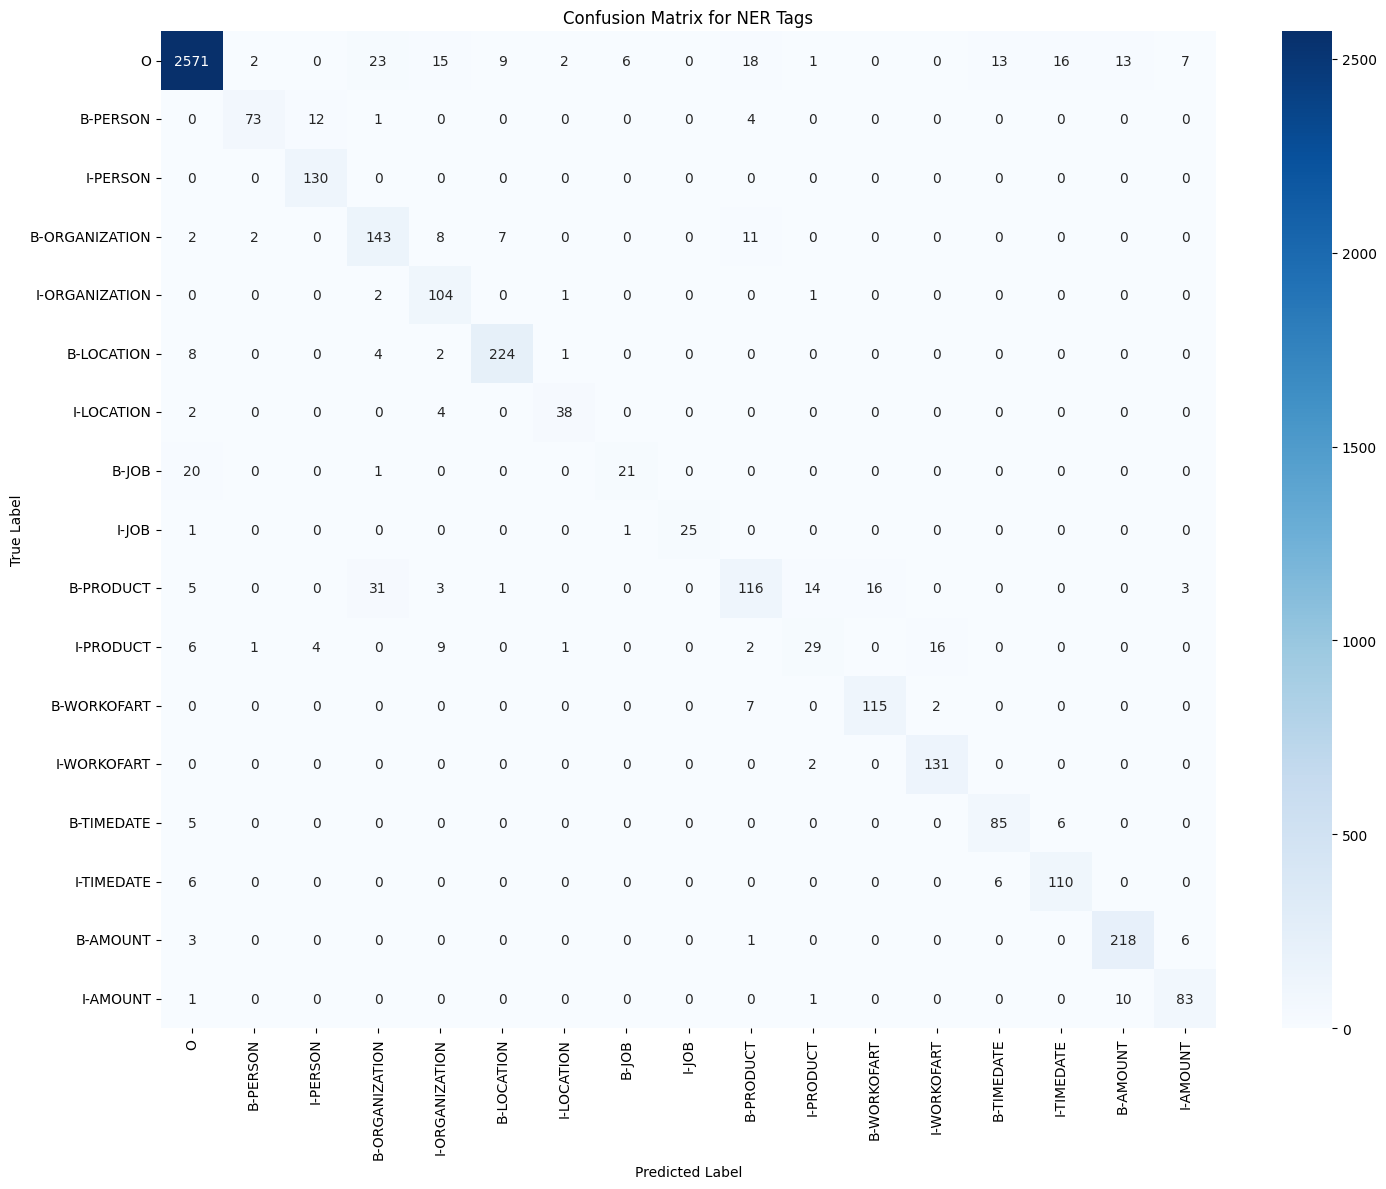

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import os, json, csv, ast # Added os, json, csv, ast
from datasets import Dataset # Added Dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification # Added needed transformers classes

# --- Re-initialize necessary components from the training script ---
# This is needed because `trainer`, `ds_test`, `label_names` etc. were defined
# inside the `main` function of the training script and are not globally available.

output_dir = "model_out"
data_dir = "."
max_length = 256
model_name_for_tokenizer = "xlm-roberta-base" # Assuming this was the base model used for tokenizer

def parse_list(v):
    if isinstance(v, list): return v
    try: return json.loads(v)
    except json.JSONDecodeError: return ast.literal_eval(v)

def read_split(path):
    tokens, tags = [], []
    for d in csv.DictReader(open(path, encoding="utf-8")):
        tk = parse_list(d["tokens"]); tg = parse_list(d["ner_tags"])
        if tk and len(tk) == len(tg):
            tokens.append(tk); tags.append(tg)
    return {"tokens": tokens, "ner_tags": tags}

# Load labels
lab = json.load(open(os.path.join(data_dir, "label_list.json")))
id2label = {int(k): v for k, v in lab["id2label"].items()}
label2id = {k: int(v) for k, v in lab["label2id"].items()}
label_names = [id2label[i] for i in range(len(id2label))]

# Load tokenizer
tok = AutoTokenizer.from_pretrained(model_name_for_tokenizer) # Use original base model name for tokenizer if not saved with model_out

# Define align function (requires `tok` and `label2id`)
def align(batch):
    enc = tok(batch["tokens"], truncation=True, is_split_into_words=True,
              max_length=max_length)
    all_labels = []
    for i, tags in enumerate(batch["ner_tags"]):
        word_ids = enc.word_ids(batch_index=i)
        prev = None; lab_ids = []
        for wid in word_ids:
            if wid is None:
                lab_ids.append(-100)
            elif wid != prev:
                lab_ids.append(label2id[tags[wid]])
            else:
                # subword continuation: keep same label but as I- (or -100)
                t = tags[wid]
                lab_ids.append(label2id[t])
            prev = wid
        all_labels.append(lab_ids)
    enc["labels"] = all_labels
    return enc

# Load and preprocess test dataset
test_raw  = read_split(os.path.join(data_dir, "test.csv"))
ds_test  = Dataset.from_dict(test_raw)
ds_test  = ds_test.map(align,  batched=True, remove_columns=ds_test.column_names)

# Load the fine-tuned model
model = AutoModelForTokenClassification.from_pretrained(
    output_dir, num_labels=len(label_names), id2label=id2label, label2id=label2id)

# Create dummy TrainingArguments and Trainer just for prediction
# The actual training arguments from the training run are not strictly needed for prediction
args = TrainingArguments(
    output_dir="./tmp_trainer_output", # Temporary output dir, as we only need predict
    per_device_eval_batch_size=16, # Use a reasonable batch size
    do_train=False, do_eval=True,
)

# Instantiate DataCollatorForTokenClassification
collator = DataCollatorForTokenClassification(tok)

trainer = Trainer(model=model, args=args, eval_dataset=ds_test, data_collator=collator)

# --- End of re-initialization ---

# Get predictions from the trainer
predictions = trainer.predict(ds_test)
logits = predictions.predictions
labels = predictions.label_ids

# Convert logits to predicted labels
preds = np.argmax(logits, axis=2)

# Align true and predicted labels, similar to compute_metrics
true_pred_flat, true_lab_flat = [], []
for pr, la in zip(preds, labels):
    for p_i, l_i in zip(pr, la):
        if l_i != -100: # Ignore padding tokens
            true_pred_flat.append(label_names[p_i])
            true_lab_flat.append(label_names[l_i])

# Calculate the confusion matrix
# We need to explicitly pass `labels` to ensure all possible tags are included
cm = confusion_matrix(true_lab_flat, true_pred_flat, labels=label_names)

# Plot the confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for NER Tags")
plt.tight_layout()
plt.show()

## Classification Report

Now, let's generate a classification report to get a detailed breakdown of the model's performance (precision, recall, F1-score, and support) for each individual named entity tag, as well as overall averages.

In [7]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(true_lab_flat, true_pred_flat, labels=label_names, target_names=label_names, zero_division=0)

print("Classification Report:")
print(report)

Classification Report:
                precision    recall  f1-score   support

             O       0.98      0.95      0.97      2696
      B-PERSON       0.94      0.81      0.87        90
      I-PERSON       0.89      1.00      0.94       130
B-ORGANIZATION       0.70      0.83      0.76       173
I-ORGANIZATION       0.72      0.96      0.82       108
    B-LOCATION       0.93      0.94      0.93       239
    I-LOCATION       0.88      0.86      0.87        44
         B-JOB       0.75      0.50      0.60        42
         I-JOB       1.00      0.93      0.96        27
     B-PRODUCT       0.73      0.61      0.67       189
     I-PRODUCT       0.60      0.43      0.50        68
   B-WORKOFART       0.88      0.93      0.90       124
   I-WORKOFART       0.88      0.98      0.93       133
    B-TIMEDATE       0.82      0.89      0.85        96
    I-TIMEDATE       0.83      0.90      0.87       122
      B-AMOUNT       0.90      0.96      0.93       228
      I-AMOUNT       0.8

## Save Model to Google Drive

To save the trained model and its artifacts to your Google Drive, we first need to mount Google Drive. After mounting, we will copy the `model_out` directory.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import shutil
import os

source_dir = "model_out"
destination_dir = "/content/drive/MyDrive/ner_model_artifacts"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Copy the entire directory
shutil.copytree(source_dir, destination_dir, dirs_exist_ok=True)

print(f"Model artifacts from '{source_dir}' successfully copied to '{destination_dir}'")

Model artifacts from 'model_out' successfully copied to '/content/drive/MyDrive/ner_model_artifacts'


In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
eval_benchmark.py

Evaluate a trained token-classification model on the REAL hand-annotated
benchmark (benchmark_full.csv). This is the honest test: the benchmark is real
news text the model never saw, annotated by hand to your rules. Compare these
numbers to your synthetic-influenced test set to see true generalization.

It:
  1. loads the model + tokenizer from --model-dir
  2. tokenizes each benchmark sentence, runs prediction
  3. converts char-offset gold entities -> token BIO aligned the same way
  4. reports entity-level precision/recall/F1 overall + per label (seqeval)
  5. optionally dumps per-sentence errors (--errors errors.txt) so you can see
     exactly where the model fails (great for the next data-fix iteration).
  6. optionally dumps all predictions, true labels, and words to a JSON file
     (--output-predictions predictions.json)

Usage:
    python eval_benchmark.py --model-dir model_out --benchmark benchmark_full.csv
    python eval_benchmark.py --model-dir model_out --benchmark benchmark_full.csv \
        --errors benchmark_errors.txt --output-predictions benchmark_predictions.json
"""
import csv, json, ast, argparse, re
import numpy as np
import os # Added import for os module

SCHEMA=["PERSON","ORGANIZATION","LOCATION","JOB","PRODUCT","WORKOFART","TIMEDATE","AMOUNT"]

def parse_cell(v):
    if isinstance(v,(list,dict)): return v
    if not isinstance(v,str) or not v.strip(): return []
    try: return json.loads(v)
    except json.JSONDecodeError: return ast.literal_eval(v)

_tok_re=re.compile(r"\S+")
def tokenize_offsets(text):
    return [(m.group(0),m.start(),m.end()) for m in _tok_re.finditer(text)]

def gold_bio(text, entities):
    toks=tokenize_offsets(text)
    tags=["O"]*len(toks)
    for e in sorted(entities,key=lambda x:(x["start"],-(x["end"]-x["start"]))):
        started=False
        for i,(tk,s,en) in enumerate(toks):
            if s<e["end"] and e["start"]<en:
                if tags[i]=="O":
                    tags[i]=("B-" if not started else "I-")+e["label"]
                    started=True
    return [t[0] for t in toks], tags

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument("--model-dir",required=True)
    ap.add_argument("--benchmark",required=True)
    ap.add_argument("--errors")
    ap.add_argument("--output-predictions", help="Path to output file for predictions (e.g., predictions.json)")
    ap.add_argument("--max-length",type=int,default=256)

    # Provide arguments directly since this is run in a notebook
    # and not from the command line.
    custom_args = [
        "--model-dir", "/content/drive/MyDrive/ner_model_artifacts",
        "--benchmark", "benchmark_full.csv",
        "--output-predictions", "benchmark_predictions.json" # Added output predictions argument
    ]
    a=ap.parse_args(args=custom_args)

    # Ensure local model directory is resolved correctly
    model_dir_path = os.path.abspath(a.model_dir)
    if not os.path.exists(model_dir_path):
        print(f"Error: Model directory '{model_dir_path}' does not exist.")
        return # Exit if model directory is not found
    else:
        print(f"Loading model from local path: {model_dir_path}")

    import torch
    from transformers import AutoTokenizer, AutoModelForTokenClassification
    import evaluate
    seqeval=evaluate.load("seqeval")

    # Use the absolute path for loading the model and tokenizer
    tok=AutoTokenizer.from_pretrained(model_dir_path)
    model=AutoModelForTokenClassification.from_pretrained(model_dir_path)
    model.eval()
    id2label=model.config.id2label

    # Ensure benchmark file exists
    benchmark_file_path = os.path.abspath(a.benchmark)
    if not os.path.exists(benchmark_file_path):
        print(f"Error: Benchmark file '{benchmark_file_path}' does not exist.")
        return # Exit if benchmark file is not found
    else:
        print(f"Loading benchmark from local path: {benchmark_file_path}")

    rows=list(csv.DictReader(open(benchmark_file_path,encoding="utf-8")))
    all_true=[]; all_pred=[]; error_lines=[]
    sentence_results = [] # To store detailed results for output file

    for r in rows:
        text=r["text"]; ents=parse_cell(r["entities"])
        words, gold = gold_bio(text, ents)
        if not words: continue
        enc=tok(words, is_split_into_words=True, return_tensors="pt",
                truncation=True, max_length=a.max_length)
        with torch.no_grad():
            logits=model(**enc).logits
        preds=logits.argmax(-1)[0].tolist()
        word_ids=enc.word_ids(0)
        pred_tags=["O"]*len(words); seen=set()
        for idx,wid in enumerate(word_ids):
            if wid is None or wid in seen: continue
            seen.add(wid)
            pred_tags[wid]=id2label[preds[idx]]
        all_true.append(gold); all_pred.append(pred_tags)

        sentence_results.append({
            "text": text,
            "words": words,
            "true_labels": gold,
            "predicted_labels": pred_tags
        })

        # record errors
        for w,g,p in zip(words,gold,pred_tags):
            if g!=p:
                error_lines.append(f"[{r['id']}] {w!r}  gold={g}  pred={p}")

    res=seqeval.compute(predictions=all_pred, references=all_true, zero_division=0)
    print("="*56); print("BENCHMARK EVALUATION (real, hand-annotated)"); print("="*56)
    print(f"  sentences      : {len(all_true)}")
    print(f"  overall precision: {res['overall_precision']:.4f}")
    print(f"  overall recall   : {res['overall_recall']:.4f}")
    print(f"  overall F1       : {res['overall_f1']:.4f}")
    print(f"  overall accuracy : {res['overall_accuracy']:.4f}")
    print("\n  Per-label:")
    print(f"    {'label':14}{'P':>8}{'R':>8}{'F1':>8}{'support':>9}")
    for lab in SCHEMA:
        if lab in res:
            d=res[lab]
            print(f"    {lab:14}{d['precision']:8.3f}{d['recall']:8.3f}{d['f1']:8.3f}{d['number']:9}")
        else:
            print(f"    {lab:14}{'--':>8}{'--':>8}{'--':>8}{0:9}")

    if a.errors:
        open(a.errors,"w",encoding="utf-8").write("\n".join(error_lines))
        print(f"\n  Wrote {len(error_lines)} token errors -> {a.errors}")

    if a.output_predictions:
        with open(a.output_predictions, "w", encoding="utf-8") as f:
            json.dump(sentence_results, f, indent=2)
        print(f"\n  Wrote predictions for {len(sentence_results)} sentences -> {a.output_predictions}")

if __name__=="__main__":
    main()

Loading model from local path: /content/drive/MyDrive/ner_model_artifacts


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading benchmark from local path: /content/benchmark_full.csv
BENCHMARK EVALUATION (real, hand-annotated)
  sentences      : 44
  overall precision: 0.8058
  overall recall   : 0.8750
  overall F1       : 0.8390
  overall accuracy : 0.9547

  Per-label:
    label                P       R      F1  support
    PERSON           1.000   1.000   1.000       29
    ORGANIZATION     0.720   0.783   0.750       23
    LOCATION         0.750   0.900   0.818       10
    JOB              0.867   0.684   0.765       19
    PRODUCT          0.818   1.000   0.900        9
    WORKOFART        0.923   1.000   0.960       12
    TIMEDATE         0.667   0.857   0.750       14
    AMOUNT           0.625   0.833   0.714       12

  Wrote predictions for 44 sentences -> benchmark_predictions.json


In [11]:
import pandas as pd
df = pd.read_json("benchmark_predictions.json")
df.head()

,text,words,true_labels,predicted_labels
0,OpenAI's release of ChatGPT in late 2022 kicke...,"[OpenAI's, release, of, ChatGPT, in, late, 202...","[B-ORGANIZATION, O, O, B-PRODUCT, O, B-TIMEDAT...","[B-ORGANIZATION, O, O, B-PRODUCT, O, B-TIMEDAT..."
1,"Meta has Meta AI, Google has Gemini.","[Meta, has, Meta, AI,, Google, has, Gemini.]","[B-ORGANIZATION, O, B-PRODUCT, I-PRODUCT, B-OR...","[B-ORGANIZATION, O, B-PRODUCT, I-PRODUCT, B-OR..."
2,Amazon has Rufus.,"[Amazon, has, Rufus.]","[B-ORGANIZATION, O, B-PRODUCT]","[B-ORGANIZATION, O, B-PRODUCT]"
3,Apple even relaunched Siri.,"[Apple, even, relaunched, Siri.]","[B-ORGANIZATION, O, O, B-PRODUCT]","[B-ORGANIZATION, O, O, B-PRODUCT]"
4,"Meta's Reality Labs, which is responsible for ...","[Meta's, Reality, Labs,, which, is, responsibl...","[B-ORGANIZATION, B-ORGANIZATION, I-ORGANIZATIO...","[B-ORGANIZATION, I-ORGANIZATION, I-ORGANIZATIO..."


In [12]:
import shutil
import os

source_file = "benchmark_predictions.json"
destination_path = "/content/drive/MyDrive/benchmark_predictions.json"

# Ensure the parent directory exists in Google Drive
destination_dir = os.path.dirname(destination_path)
os.makedirs(destination_dir, exist_ok=True)

# Copy the file to Google Drive
shutil.copy(source_file, destination_path)

print(f"Successfully copied '{source_file}' to '{destination_path}'")

Successfully copied 'benchmark_predictions.json' to '/content/drive/MyDrive/benchmark_predictions.json'
